In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models
from midas.data.dataloader import MIDASDataset, PADDataset
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score, f1_score, roc_auc_score, precision_recall_curve)
from PIL import Image
from skimage import color

In [2]:
class LABAugmentation:
    def __init__(self, t_range=(-0.3, 1.0), a_scale=10.0, b_scale=16.0, l_shift_range=(-8, 3), p=0.5):
        self.t_range = t_range
        self.a_scale = a_scale
        self.b_scale = b_scale
        self.l_shift_range = l_shift_range
        self.p = p

    def __call__(self, image: Image.Image):
        image_np = np.array(image).astype(np.float32) / 255.0
        lab = color.rgb2lab(image_np)

        t = np.random.uniform(*self.t_range)
        a_shift = t * self.a_scale
        b_shift = t * self.b_scale

        l_shift = np.random.uniform(*self.l_shift_range)

        lab[:, :, 0] = np.clip(lab[:, :, 0] + l_shift, 0, 100)
        lab[:, :, 1] = np.clip(lab[:, :, 1] + a_shift, -128, 127)
        lab[:, :, 2] = np.clip(lab[:, :, 2] + b_shift, -128, 127)

        rgb = color.lab2rgb(lab)
        return Image.fromarray((np.clip(rgb, 0, 1) * 255).astype(np.uint8))

In [11]:
augment_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.RandomResizedCrop(224, scale=(0.65, 1.0)), 
                    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(), transforms.RandomRotation(180),
                    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.4), 
                    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)), transforms.ColorJitter(brightness=0.2, contrast=0.2), 
                    LABAugmentation(t_range=(-0.15, 0.9), a_scale=10.0, b_scale=16.0, l_shift_range=(-3, 6), p=0.6), transforms.ToTensor(), 
                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

standard_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), 
                     (0.5, 0.5, 0.5))])
metadata = pd.read_csv("/Users/oliviagleason/Documents/year three/term nine/dsci 410L/project/midas.csv")

train_ids, test_ids = train_test_split(metadata["midas_record_id"].unique(), test_size=0.15, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=0.1765, random_state=42)

train_df = metadata[metadata["midas_record_id"].isin(train_ids)]
val_df = metadata[metadata["midas_record_id"].isin(val_ids)]
test_df = metadata[metadata["midas_record_id"].isin(test_ids)]
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [12]:
def compute_age_stats(df, column):
    ages = df[column].values.astype(float)
    mean = np.mean(ages)
    std = np.std(ages)
    return mean, std

age_mean, age_std = compute_age_stats(train_df, "midas_age")

In [13]:
original_dataset = MIDASDataset(data_dir="/Users/oliviagleason/Documents/year three/term nine/dsci 410L/project/MIDAS", 
                       csv_file="train.csv", transform=standard_transform, age_mean=age_mean, age_std=age_std)
augmented_dataset = MIDASDataset(data_dir="/Users/oliviagleason/Documents/year three/term nine/dsci 410L/project/MIDAS", 
                       csv_file="train.csv", transform=augment_transform, age_mean=age_mean, age_std=age_std)
train_dataset = ConcatDataset([original_dataset, augmented_dataset])
val_dataset = MIDASDataset(data_dir="/Users/oliviagleason/Documents/year three/term nine/dsci 410L/project/MIDAS", 
                       csv_file="val.csv", transform=standard_transform, age_mean=age_mean, age_std=age_std)
test_dataset = MIDASDataset(data_dir="/Users/oliviagleason/Documents/year three/term nine/dsci 410L/project/MIDAS", 
                       csv_file="test.csv", transform=standard_transform, age_mean=age_mean, age_std=age_std)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..0.8509804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9372549].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..0.8745098].


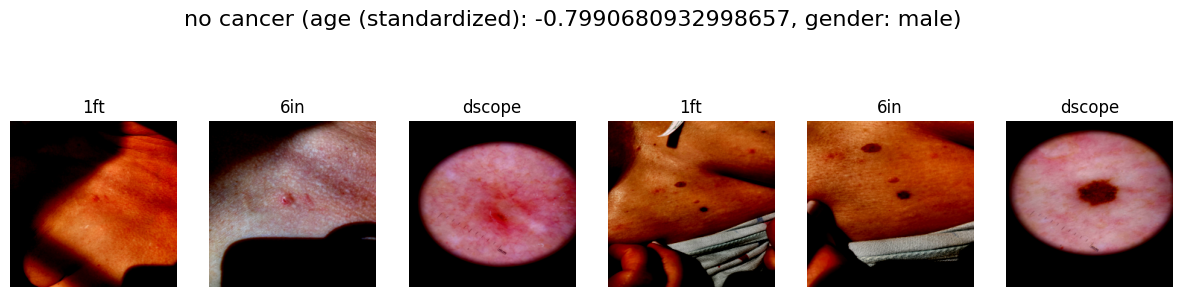

In [40]:
images, image_types, metadata, labels = next(iter(train_loader))
patient_images = images[0] 
patient_img_types = image_types[0]
patient_metadata = metadata[0]

type_map = {0: "dscope", 1: "6in", 2: "1ft", 3: "n/a - virtual"}
gender_map = {0: "female", 1: "male"}
class_map = {0: "no cancer", 1: "cancer"}

plt.figure(figsize=(15, 4))
for i in range(patient_images.shape[0]):
    image = patient_images[i].permute(1, 2, 0)
    plt.subplot(1, patient_images.shape[0], i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(type_map[int(patient_img_types[i])])
plt.suptitle(f"{class_map[int(labels)]} (age (standardized): {float(patient_metadata[0])}, gender: {gender_map[int(patient_metadata[1])]})", fontsize=16)
plt.show()

In [65]:
class PatientModel(nn.Module):
    def __init__(self, meta_dim=2):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = backbone.fc.in_features

        self.attention = nn.Sequential(nn.Linear(self.feature_dim, 128), nn.Tanh(), nn.Linear(128, 1))
        self.meta_layer = nn.Linear(meta_dim, 32)
        self.classifier = nn.Sequential(nn.Linear(self.feature_dim + 32, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, images, metadata):
        feats = []
        for img in images:
            f = self.encoder(img.unsqueeze(0))
            feats.append(f.view(-1))
        feats = torch.stack(feats)

        attn_logits = self.attention(feats)
        attn_weights = torch.softmax(attn_logits.squeeze(-1), dim=0)
        attn_weights = attn_weights.unsqueeze(-1)

        pooled = (feats * attn_weights).sum(dim=0)
        meta_feat = self.meta_layer(metadata.float())

        x = torch.cat([pooled, meta_feat], dim=0)
        x = x.unsqueeze(0)
        out = self.classifier(x)
        return out.squeeze()

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PatientModel().to(device)

pos_weight = torch.tensor([3.0]).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

for name, param in model.encoder.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=7e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

def find_best_threshold(y_true, probs):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)

    return thresholds[best_idx], f1_scores[best_idx]

def get_probs_and_labels(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, _, metadata, label in loader:
            images = images.squeeze(0).to(device)
            metadata = metadata.squeeze(0).to(device).float()

            logits = model(images, metadata)

            prob = torch.sigmoid(logits).view(-1)

            all_probs.append(prob.cpu())
            all_labels.append(label.view(-1).cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_probs

def evaluate(model, loader):

    y_true, probs = get_probs_and_labels(model, loader)

    print(f"Pred range: {probs.min():.4f} - {probs.max():.4f}")

    auc = roc_auc_score(y_true, probs)

    best_thresh, best_f1 = find_best_threshold(y_true, probs)

    preds = (probs >= best_thresh).astype(int)

    acc = accuracy_score(y_true, preds)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    return auc, acc, recall, f1, best_thresh

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, _, metadata, label in loader:

        images = images.squeeze(0).to(device)
        metadata = metadata.squeeze(0).to(device).float()
        label = label.float().to(device)

        optimizer.zero_grad()

        logits = model(images, metadata) 

        loss = criterion(logits.view(1), label.view(1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

num_epochs = 30
best_auc = 0
best_state = None

patience = 4
no_improve = 0

for epoch in range(num_epochs):

    train_loss = train_one_epoch(model, train_loader)

    val_auc, val_acc, val_recall, val_f1, best_thresh = evaluate(model, val_loader)

    scheduler.step(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
        print(f"✓ New best AUC: {best_auc:.4f}")
    else:
        no_improve += 1

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"AUC: {val_auc:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"Recall: {val_recall:.4f} | "
        f"F1: {val_f1:.4f} | "
        f"Thresh: {best_thresh:.3f}"
    )

    if no_improve >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(best_state)
print(f"\n✅ Best AUC: {best_auc:.4f}")


Pred range: 0.2065 - 0.4005
✓ New best AUC: 0.5679
Epoch 1 | Loss: 0.8814 | AUC: 0.5679 | Acc: 0.5825 | Recall: 0.6538 | F1: 0.4416 | Thresh: 0.298
Pred range: 0.2721 - 0.4258
Epoch 2 | Loss: 0.8666 | AUC: 0.5385 | Acc: 0.4563 | Recall: 0.9231 | F1: 0.4615 | Thresh: 0.324
Pred range: 0.2469 - 0.4120
Epoch 3 | Loss: 0.8672 | AUC: 0.5270 | Acc: 0.5340 | Recall: 0.6923 | F1: 0.4286 | Thresh: 0.319
Pred range: 0.2220 - 0.4104
Epoch 4 | Loss: 0.8660 | AUC: 0.5095 | Acc: 0.6117 | Recall: 0.5385 | F1: 0.4118 | Thresh: 0.325
Pred range: 0.2562 - 0.4050
Epoch 5 | Loss: 0.8702 | AUC: 0.5295 | Acc: 0.2621 | Recall: 1.0000 | F1: 0.4062 | Thresh: 0.258
Early stopping triggered

✅ Best AUC: 0.5679


In [71]:
PAD_metadata = pd.read_csv("/Users/oliviagleason/Documents/year three/term nine/dsci 410L/project/PAD-UFES-20/metadata.csv")
PAD_metadata.to_csv("PAD_metadata.csv", index=False)

PAD_dataset = PADDataset(data_dir="/Users/oliviagleason/Documents/year three/term nine/dsci 410L/project/PAD-UFES-20/images", 
                       csv_file="PAD_metadata.csv", transform=standard_transform, age_mean=age_mean, age_std=age_std)
PAD_loader = DataLoader(PAD_dataset, batch_size=1, shuffle=True)

def test_evaluate(model, loader, threshold):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, _, metadata, label in loader:
            images = images.squeeze(0).to(device)
            metadata = metadata.squeeze(0).to(device).float()

            logits = model(images, metadata)
            prob = torch.sigmoid(logits).item()

            all_probs.append(prob)
            all_labels.append(label)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    print(f"Test Pred range: {all_probs.min():.4f} - {all_probs.max():.4f}")

    auc = roc_auc_score(all_labels, all_probs)

    preds = (all_probs >= threshold).astype(int)

    acc = accuracy_score(all_labels, preds)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)

    print(f"AUC: {auc:.4f}")
    print(f"Acc: {acc:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Threshold used: {threshold:.3f}")

    return auc, acc, recall, f1

test_evaluate(model, PAD_loader, 0.298)

Test Pred range: 0.1929 - 0.4891
AUC: 0.4123
Acc: 0.4319
Recall: 0.9141
F1: 0.5820
Threshold used: 0.298


(np.float64(0.4123433738324624),
 0.4319009468317553,
 0.9141414141414141,
 0.5819935691318328)